Running optimizer: AdaGramPS...
Running optimizer: Kate...
Running optimizer: Adagrad...
Running optimizer: SGD...
All optimizations complete.


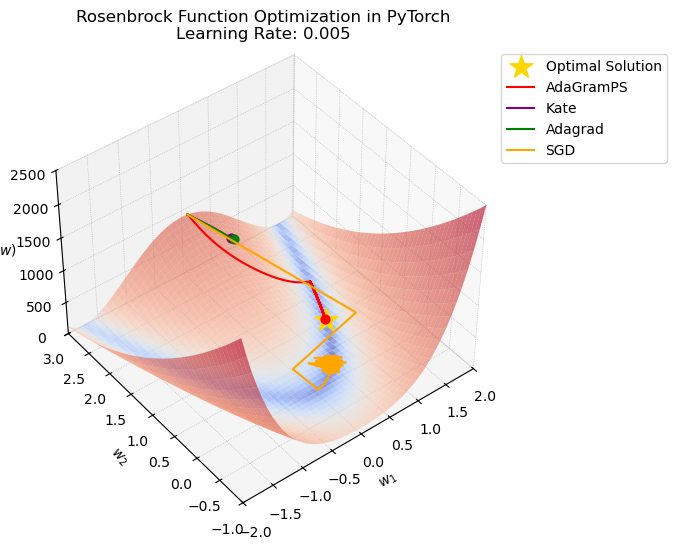

In [6]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

import libcontext
from src.AdagramVanilla import AdaGramVanilla
from src.AdagramPS import AdaGramPS
from src.Shampoo import Shampoo
from src.FullAdagrad import FullAdaGrad
from src.Kate import KATE

from IPython.display import HTML
import matplotlib

matplotlib.rcParams['animation.embed_limit'] = 50

# --- Matplotlib Configuration ---
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.linestyle'] = ":"
plt.rcParams['figure.dpi'] = 100

# --- Rosenbrock Function using PyTorch ---
def f(w):
    """Rosenbrock function for optimization."""
    w1, w2 = w
    return (1 - w1)**2 + 100 * (w2 - w1**2)**2

# --- Simulation Parameters ---
N_ITER = 2000
TOTAL_FRAMES = 300
LR = 5e-3
MOMENTUM = 0.9
W_0 = torch.tensor([0.1, 3.0])
BOUNDS_W1 = (-2, 2)
BOUNDS_W2 = (-1, 3)

# --- Optimizer Configuration ---
# Note: Replaced Optax optimizers with PyTorch equivalents.
optimizers_config = [
    # {
    #     'name': 'RMSprop',
    #     'optimizer_class': torch.optim.RMSprop,
    #     'params': {'lr': LR},
    #     'color': 'orange'
    # },
    {
        'name': 'AdaGramPS',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 1},
        'color': 'red'
    },
        {
        'name': 'Kate',
        'optimizer_class': KATE,
        'params': {'lr': LR},
        'color': 'purple'
    },
    {
        'name': 'Adagrad',
        'optimizer_class': torch.optim.Adagrad,
        'params': {'lr': LR},
        'color': 'green'
    },
    {
        'name': 'SGD',
        'optimizer_class': torch.optim.SGD,
        'params': {'lr': LR},
        'color': 'orange'
    },
    # {
    #     'name': 'AdamW',
    #     'optimizer_class': torch.optim.AdamW,
    #     'params': {'lr': LR},
    #     'color': 'purple'
    # },
]

# --- Trajectory Calculation Logic for PyTorch ---
def optimizer_trajectory(optimizer, w, n_iter=N_ITER):
    """
    Computes the optimization trajectory for a given PyTorch optimizer.
    # """
    # w = initial_w.clone().detach().requires_grad_(True)
    
    metrics = {
        "fs": [],
        "gs": [],
        "ws": [],
    }

    # Initial state
    initial_loss = f(w)
    initial_loss.backward()
    metrics["fs"].append(initial_loss.item())
    metrics["gs"].append(torch.linalg.norm(w.grad).item())
    metrics["ws"].append(w.clone().detach())
    optimizer.zero_grad()

    # Optimization loop
    for _ in range(n_iter):
        
        loss = f(w)
        loss.backward()
        optimizer.step()

        # Record metrics
        metrics["fs"].append(loss.item())
        metrics["gs"].append(torch.linalg.norm(w.grad).item())
        metrics["ws"].append(w.clone().detach())
        optimizer.zero_grad()
        
    return metrics

# --- Run Optimization for All Configured Optimizers ---
metrics = {}
for opt_config in optimizers_config:
    # Create the tensor that will be optimized for this run
    w_to_optimize = W_0.clone().detach().requires_grad_(True)
    
    # Instantiate the optimizer with THIS specific tensor
    optimizer_instance = opt_config['optimizer_class']([w_to_optimize], **opt_config['params'])
    
    print(f"Running optimizer: {opt_config['name']}...")
    # Pass both the optimizer and the tensor it's tracking
    metrics[opt_config['name']] = optimizer_trajectory(optimizer_instance, w_to_optimize)

print("All optimizations complete.")
# --- 3D Plot Setup ---
fig, ax = plt.subplots(subplot_kw=dict(projection='3d', azim=-128.0, elev=43.0, computed_zorder=False), figsize=(8, 6))

# Create the surface plot
x_grid = np.linspace(*BOUNDS_W1, 50)
y_grid = np.linspace(*BOUNDS_W2, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.array([f(torch.tensor([x_val, y_val])).item() for x_val, y_val in zip(X.flatten(), Y.flatten())]).reshape(X.shape)

ax.plot_surface(X, Y, Z, alpha=0.6, cmap='coolwarm', norm=LogNorm())
ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')
ax.set_xlim(BOUNDS_W1)
ax.set_ylim(BOUNDS_W2)
ax.set_zlim([0, 2500])
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$f(w)$', rotation=0)
ax.set_title(f'Rosenbrock Function Optimization in PyTorch\nLearning Rate: {LR}')

# Plot the global minimum
global_min = torch.tensor([1.0, 1.0])
ax.scatter(global_min[0], global_min[1], f(global_min).item(), color='gold', marker='*', s=300, label='Optimal Solution')

# Initialize empty lines for trajectories - extract the Line3D object from the list
lines = [ax.plot([], [], [], color=opt['color'], label=opt['name'])[0] for opt in optimizers_config]

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# --- Animation Logic ---
last_scatters = []

def animate(i):
    global last_scatters
    ax.view_init(azim=-128.0, elev=43.0)
    
    skip_rate = int(np.floor(N_ITER / TOTAL_FRAMES))
    if skip_rate == 0: skip_rate = 1
    
    for scatter in last_scatters:
        scatter.remove()
    last_scatters.clear()
    
    for opt_config, line in zip(optimizers_config, lines):
        name = opt_config['name']
        
        # Calculate the current slice of the trajectory
        end_index = min(i * skip_rate + 1, len(metrics[name]["ws"]))
        w_trajectory_torch = torch.stack(metrics[name]["ws"][:end_index])
        w_trajectory_np = w_trajectory_torch.numpy()
        
        # --- FIX: Use pre-computed Z-values ---
        z_trajectory = metrics[name]["fs"][:end_index]
        
        line.set_data(w_trajectory_np[:, 0], w_trajectory_np[:, 1])
        line.set_3d_properties(z_trajectory) # Use the stored values

        # Draw current point
        w_current = w_trajectory_torch[-1]
        z_current = z_trajectory[-1] # Get the corresponding z-value
        scatter = ax.scatter(w_current[0], w_current[1], z_current, color=opt_config['color'], s=40)
        last_scatters.append(scatter)

    return lines + last_scatters
# To run the animation, you would uncomment the following lines:
ani = FuncAnimation(
    fig,
    animate,
    interval=1000/30,  # Increased interval for clearer visualization
    frames=TOTAL_FRAMES,
    blit=True
)

ani.save(
    "rosenbrock_optimization.mp4", 
    writer='ffmpeg', 
    fps=30,
    # This is the key for speed
    extra_args=['-vcodec', 'libx264', '-preset', 'ultrafast']
)


# animate(TOTAL_FRAMES)
# fig.tight_layout(rect=[0, 0.03, 1, 1])
# # plt.show()
# HTML(ani.to_jshtml())